In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\3062881070.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load Data

In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [4]:
# Base scenario
base = {
    "Jan": gpd.read_file("COMBINE_ACONC_BASE_Jan2023_average.shp").to_crs("EPSG:4326"),
    "Apr": gpd.read_file("COMBINE_ACONC_BASE_202304_D03_average.shp").to_crs("EPSG:4326"),
    "Jul": gpd.read_file("COMBINE_ACONC_BASE_July2023_Average.shp").to_crs("EPSG:4326"),
    "Oct": gpd.read_file("COMBINE_ACONC_BASE_202310_D03_average.shp").to_crs("EPSG:4326"),
}

# Base scenario mda8o3
base_o3 = {
    "Jan": gpd.read_file("MDA8O3_Jan2023_Baseline_Average.shp").to_crs("EPSG:4326"),
    "Apr": gpd.read_file("MDA8O3_Apr2023_Baseline_Average.shp").to_crs("EPSG:4326"),
    "Jul": gpd.read_file("MDA8O3_July2023_BASE_Average.shp").to_crs("EPSG:4326"),
    "Oct": gpd.read_file("MDA8O3_Oct2023_Baseline_Average.shp").to_crs("EPSG:4326"),
}

In [5]:
# Idling and onroad modification scenario
idling = {
    "Jan": gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_Jan2023_avg.shp").to_crs("EPSG:4326"),
    "Apr": gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_202304_D03_average.shp").to_crs("EPSG:4326"),
    "Jul": gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_July2023_Average.shp").to_crs("EPSG:4326"),
    "Oct": gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_202310_D03_average.shp").to_crs("EPSG:4326"),
}

# Idling and onroad modification scenario mda8o3
idling_o3 = {
    "Jan": gpd.read_file("MDA8O3_LOCUSIdling_HDVSpatial_202301.shp").to_crs("EPSG:4326"),
    "Apr": gpd.read_file("MDA8O3_Apr2023_LOCUSIdling_HDVSpatial_Average.shp").to_crs("EPSG:4326"),
    "Jul": gpd.read_file("MDA8O3_July2023_LOCUSIdling_HDVSpatial_Average.shp").to_crs("EPSG:4326"),
    "Oct": gpd.read_file("MDA8O3_Oct2023_LOCUSIdling_HDVSpatial_Average.shp").to_crs("EPSG:4326"),
}

In [6]:
#clip to cmap domain 
cmap_roads = gpd.clip(primary_roads, cmap_cty)

cmap_base = {month: gpd.clip(gdf, cmap_cty) for month, gdf in base.items()}
cmap_idling = {month: gpd.clip(gdf, cmap_cty) for month, gdf in idling.items()}
cmap_base_o3 = {month: gpd.clip(gdf, cmap_cty) for month, gdf in base_o3.items()}
cmap_idling_o3 = {month: gpd.clip(gdf, cmap_cty) for month, gdf in idling_o3.items()}

<h1> Plot Total Magnitude Pollutants  

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\1209504263.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS)))


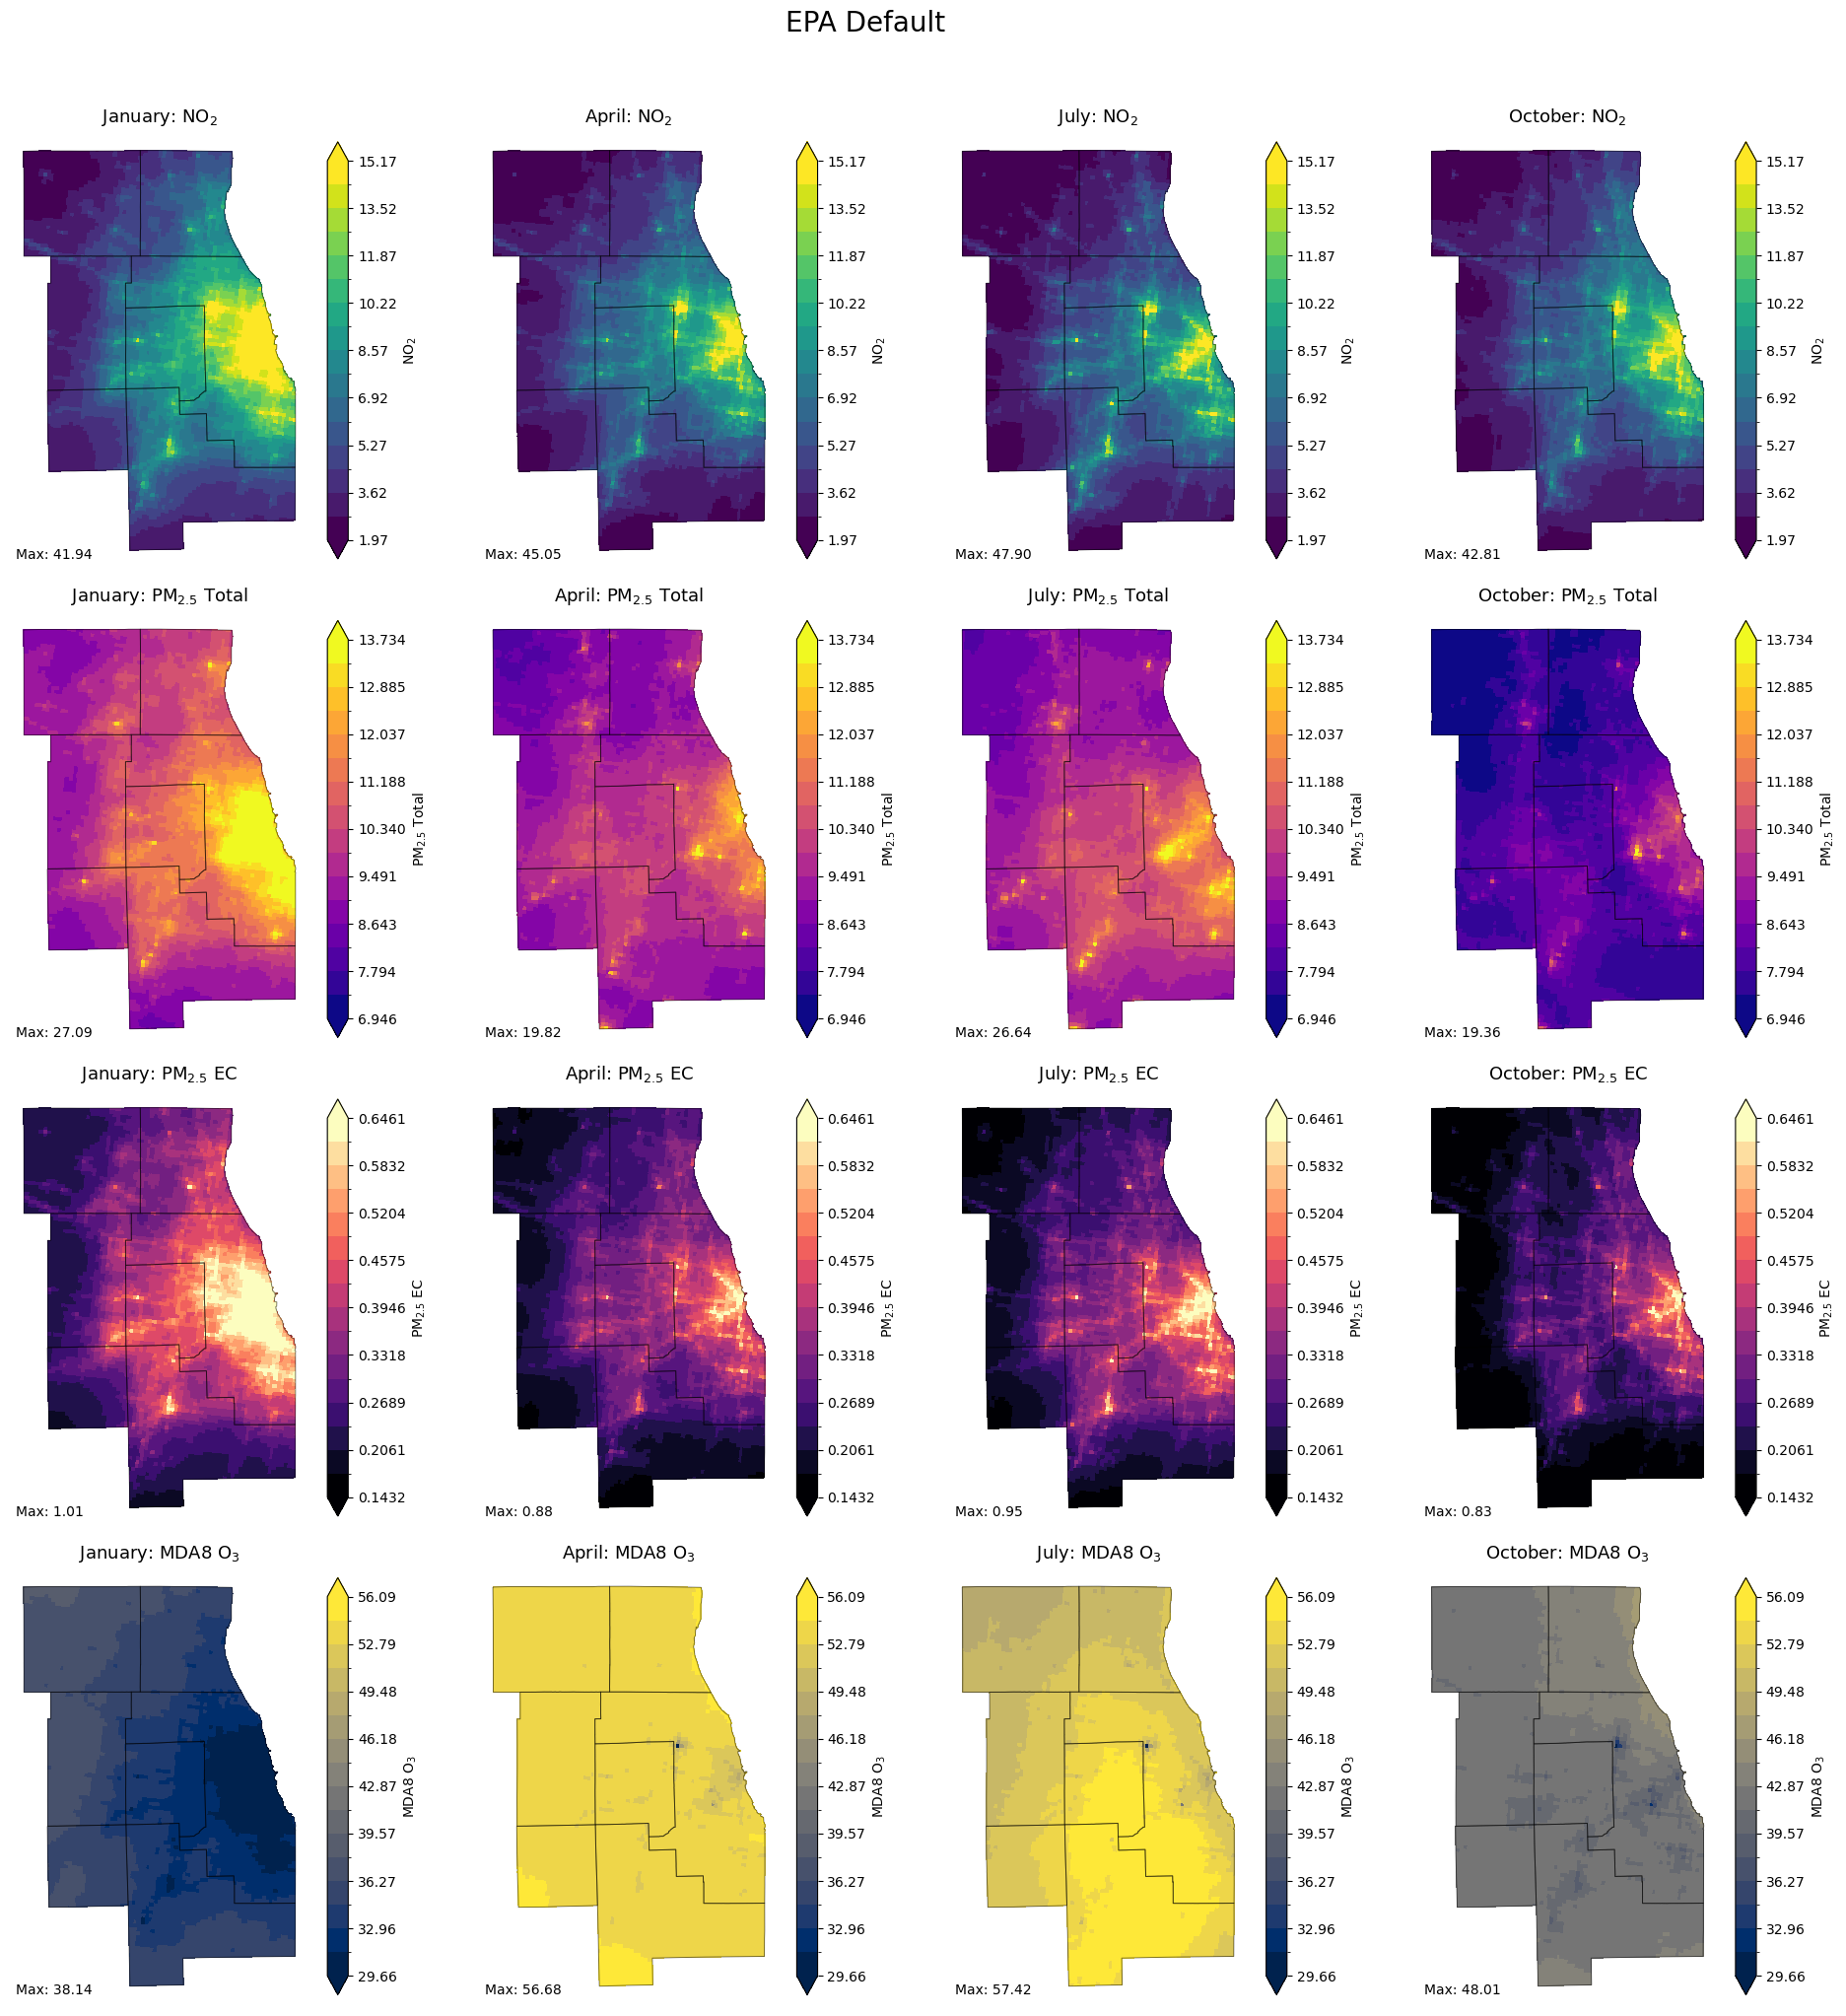

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\1209504263.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS)))


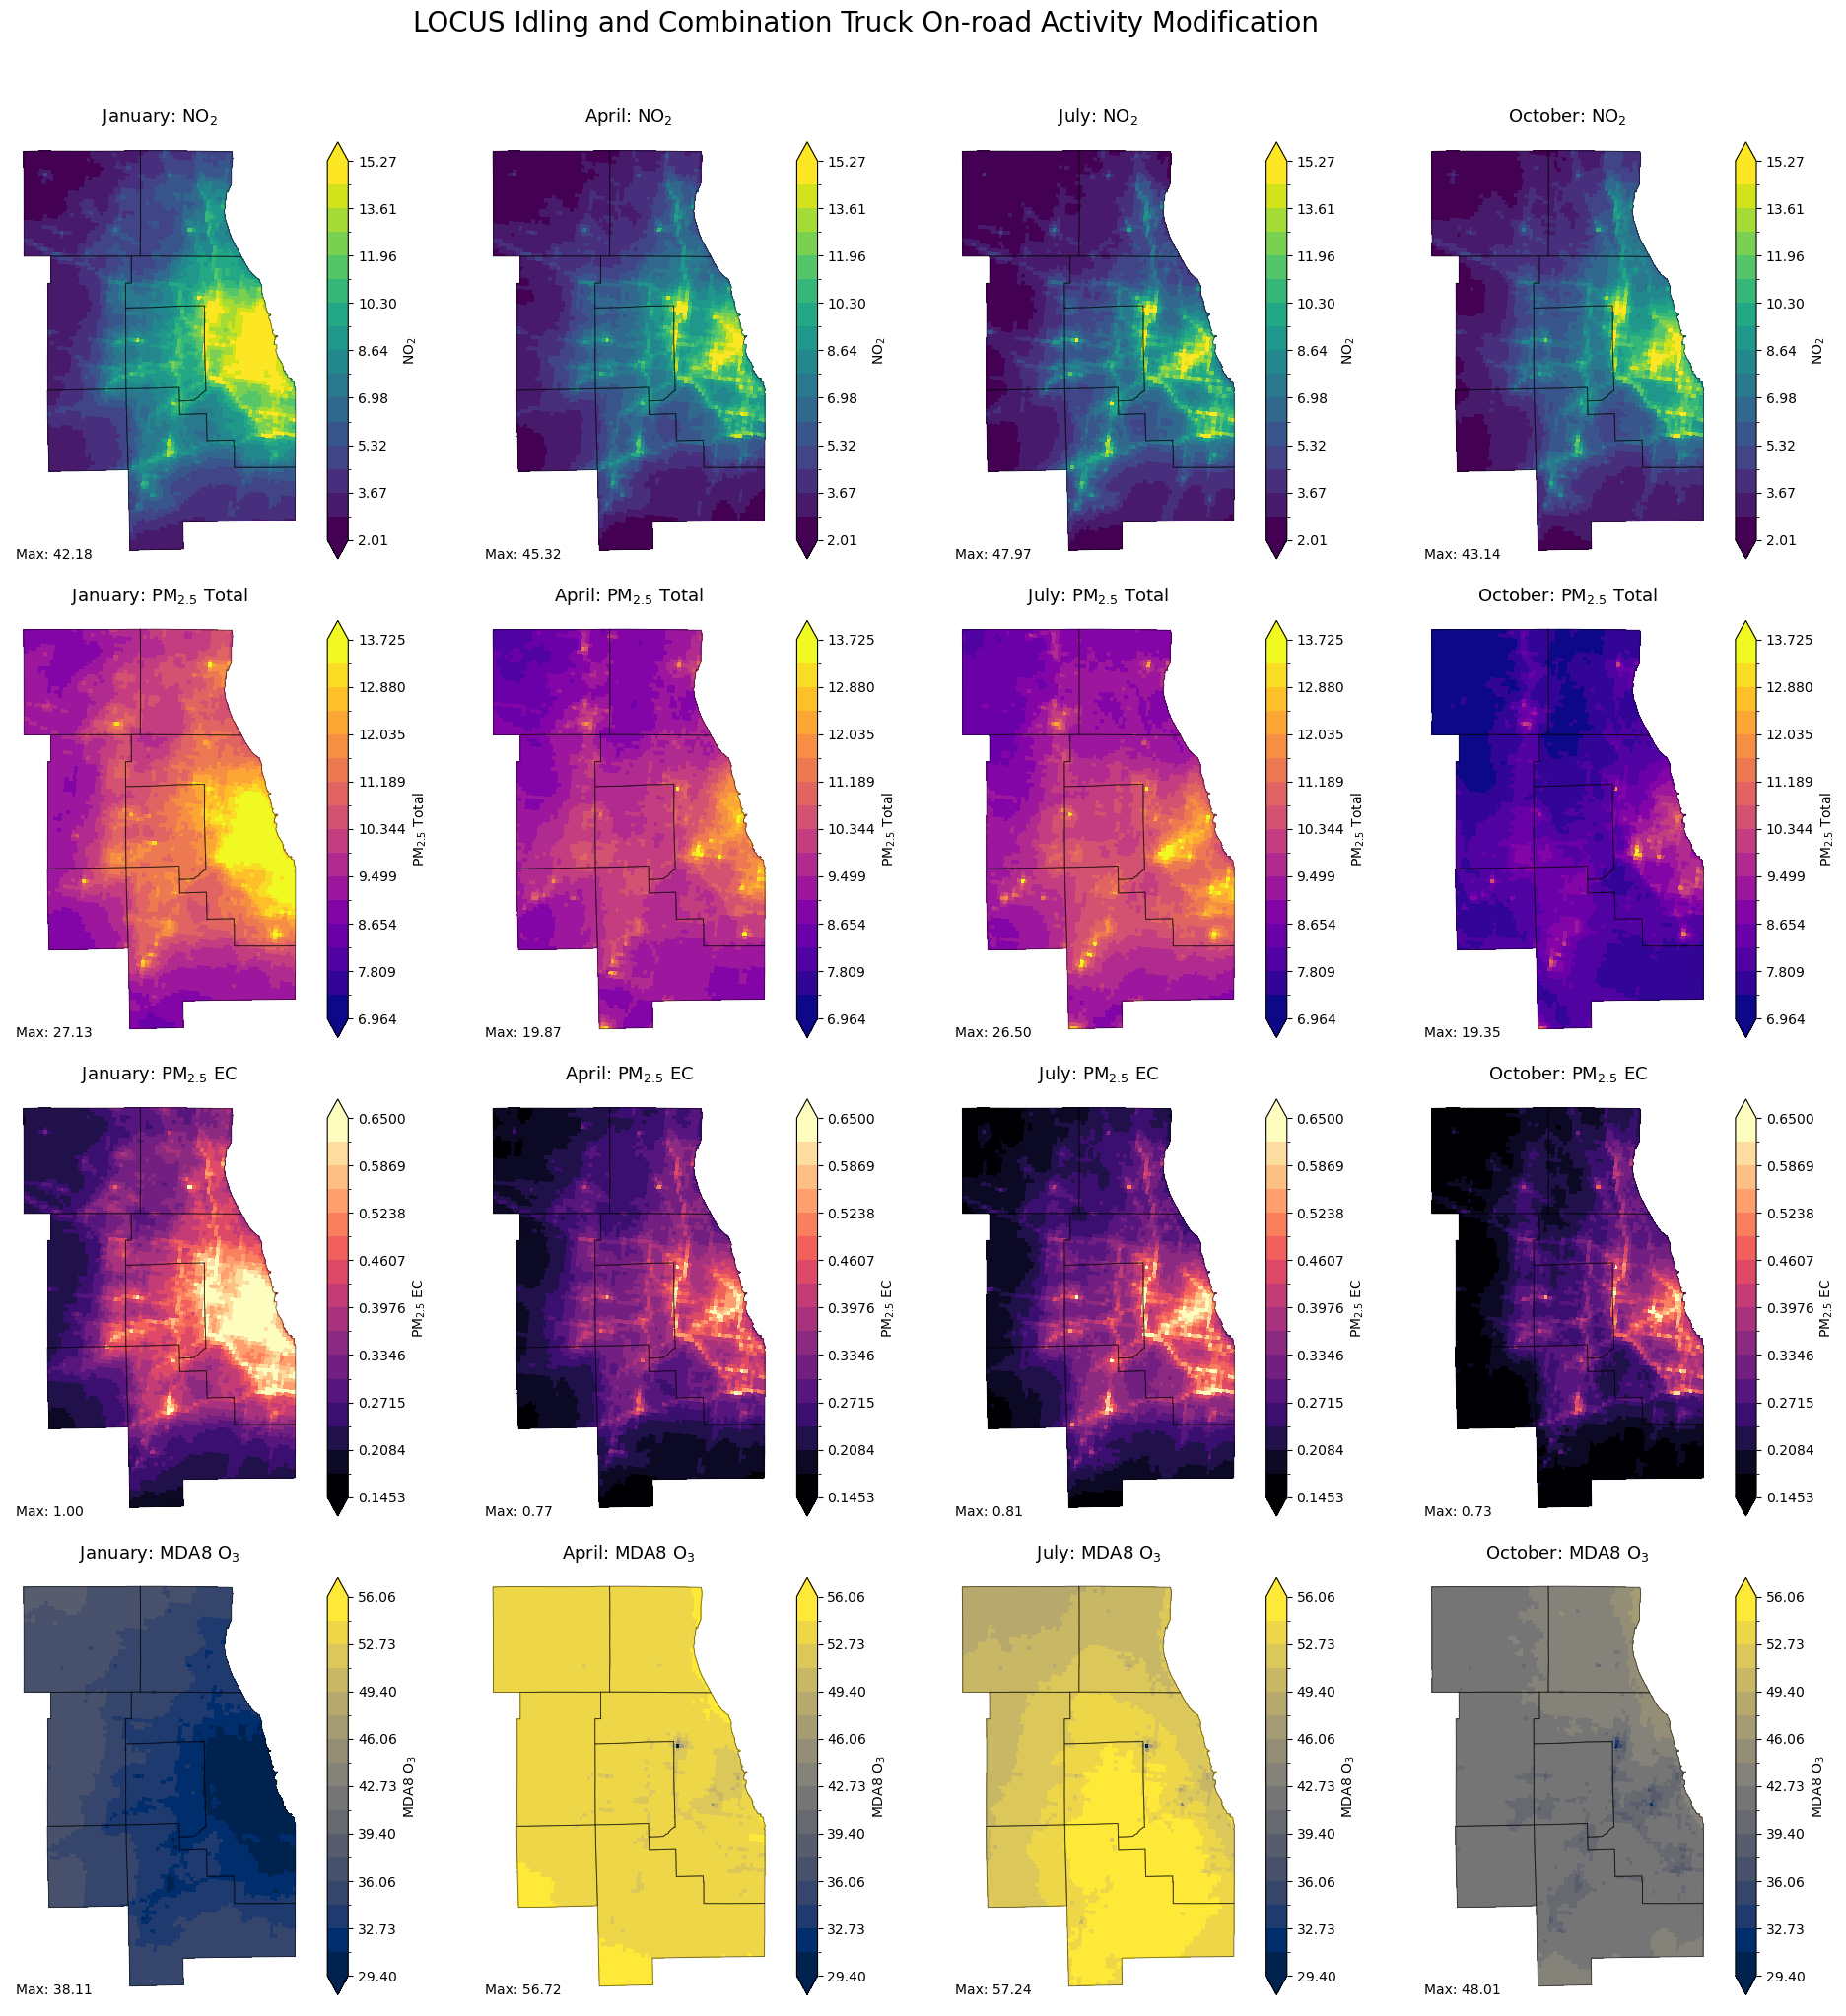

In [20]:
N_BINS = 16

plot_config = {
    "NO2": {"cmap_name": "viridis", "title": "NO$_2$", "label": "NO$_2$", "column": "NO2"},
    "PM25_TOT": {"cmap_name": "plasma", "title": "PM$_{2.5}$ Total", "label": "PM$_{2.5}$ Total", "column": "PM25_TOT"},
    "PM25_EC": {"cmap_name": "magma", "title": "PM$_{2.5}$ EC", "label": "PM$_{2.5}$ EC", "column": "PM25_EC"},
    "O3": {"cmap_name": "cividis", "title": "MDA8 O$_3$", "label": "MDA8 O$_3$", "column": "O3"},
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]
months = ["Jan", "Apr", "Jul", "Oct"]
month_labels = ["January", "April", "July", "October"]

def plot_monthly_pollutants(scenario_gdfs_by_pol, figure_title, save_name):
    pollutant_styles = {}

    # create one shared color scale for each pollutant across all four months
    for pol in pollutants:
        vals_all = []
        col = plot_config[pol]["column"]

        for month in months:
            vals = scenario_gdfs_by_pol[pol][month][col].astype(float).to_numpy()
            vals_all.append(vals[np.isfinite(vals)])

        vals_all = np.concatenate(vals_all)

        # use the 1st and 99th percentiles so extreme grid cells do not dominate the scale
        vmin = np.quantile(vals_all, 0.01)
        vmax = np.quantile(vals_all, 0.99)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        cmap_disc = ListedColormap(plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS)))
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        norm = BoundaryNorm(bounds, cmap_disc.N)

        pollutant_styles[pol] = {"vmin": vmin, "vmax": vmax, "bounds": bounds, "cmap": cmap_disc, "norm": norm}

    fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 20), subplot_kw={"projection": ccrs.PlateCarree()})
    fig.suptitle(figure_title, fontsize=20, y=1.02)

    for i, pol in enumerate(pollutants):
        col = plot_config[pol]["column"]

        for j, month in enumerate(months):
            ax = axs[i, j]
            gdf = scenario_gdfs_by_pol[pol][month]
            style = pollutant_styles[pol]

            # plot each month using the pollutant-specific shared scale
            gdf.plot(column=col, ax=ax, cmap=style["cmap"], norm=style["norm"], edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

            ax.set_title(f"{month_labels[j]}: {plot_config[pol]['title']}", fontsize=13)
            ax.set_axis_off()

            # add a discrete colorbar to each panel
            sm = plt.cm.ScalarMappable(norm=style["norm"], cmap=style["cmap"])
            sm._A = []

            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=style["bounds"], ticks=style["bounds"][::2], spacing="proportional", extend="both")
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

            # annotate the maximum concentration in each month
            vals = gdf[col].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))

            ax.text(0.02, 0.02, f"Max: {vmax_panel:.2f}", transform=ax.transAxes, ha="left", va="bottom", fontsize=10, color="black",
                    bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0))

    plt.tight_layout()

    # save a high-resolution PNG and vector PDF
    fig.savefig(f"{save_name}.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


base_monthly_gdfs_by_pol = {"NO2": cmap_base, "PM25_TOT": cmap_base, "PM25_EC": cmap_base, "O3": cmap_base_o3}
idling_monthly_gdfs_by_pol = {"NO2": cmap_idling, "PM25_TOT": cmap_idling, "PM25_EC": cmap_idling, "O3": cmap_idling_o3}


plot_monthly_pollutants(base_monthly_gdfs_by_pol, "EPA Default", "EPA_Default_Monthly_Pollutants")

plot_monthly_pollutants(
    idling_monthly_gdfs_by_pol,
    "LOCUS Idling and Combination Truck On-road Activity Modification",
    "LOCUS_Idling_Combination_Truck_Monthly_Pollutants",)

<h1> Plot Difference in Air Pollutants 

In [24]:
N_BINS = 16

months = ["Jan", "Apr", "Jul", "Oct"]
month_labels = {
    "Jan": "January",
    "Apr": "April",
    "Jul": "July",
    "Oct": "October",
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]

scenario_names = [
    "EPA Default",
    "LOCUS Idling and Combination\nTruck On-road Activity\nModification",
    "LOCUS Minus Default",
    "% Difference\nfrom Default",
]

plot_config = {
    "NO2": {"cmap_name": "viridis", "title": "NO$_2$", "label": "NO$_2$", "column": "NO2"},
    "PM25_TOT": {"cmap_name": "plasma", "title": "PM$_{2.5}$", "label": "PM$_{2.5}$", "column": "PM25_TOT"},
    "PM25_EC": {"cmap_name": "magma", "title": "EC", "label": "EC", "column": "PM25_EC"},
    "O3": {"cmap_name": "cividis", "title": "MDA8 O$_3$", "label": "MDA8 O$_3$", "column": "O3"},
}

monthly_gdfs_by_pol = {
    "NO2": {"reference": cmap_base, "scenario": cmap_idling},
    "PM25_TOT": {"reference": cmap_base, "scenario": cmap_idling},
    "PM25_EC": {"reference": cmap_base, "scenario": cmap_idling},
    "O3": {"reference": cmap_base_o3, "scenario": cmap_idling_o3},
}

def plot_monthly_default_locus(month):
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = monthly_gdfs_by_pol[pol]["reference"][month]
        scenario_gdf = monthly_gdfs_by_pol[pol]["scenario"][month]

        vals_all = []

        for gdf in [reference_gdf, scenario_gdf]:
            vals = gdf[col].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vals_all.append(vals)

        vals_all = np.concatenate(vals_all)

        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        cmap_disc = ListedColormap(
            plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
        )

        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        norm = BoundaryNorm(bounds, cmap_disc.N)

        abs_styles[pol] = {
            "bounds": bounds,
            "cmap": cmap_disc,
            "norm": norm,
        }

        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()

        diff_vals = scenario_vals - reference_vals

        pct_vals = np.where(
            reference_vals != 0,
            (diff_vals / reference_vals) * 100.0,
            np.nan,
        )

        diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
        pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

        diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

        if np.isclose(diff_lim, 0):
            diff_lim = 1e-6
        if np.isclose(pct_lim, 0):
            pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

        diff_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
        )

        pct_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
        )

        diff_styles[pol] = {
            "diff_bounds": diff_bounds,
            "diff_cmap": diff_cmap,
            "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
            "pct_bounds": pct_bounds,
            "pct_cmap": pct_cmap,
            "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
        }

    scenario_gdfs_by_pol = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = monthly_gdfs_by_pol[pol]["reference"][month]
        scenario_gdf = monthly_gdfs_by_pol[pol]["scenario"][month]

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = plot_reference[col].astype(float)
        plot_scenario[pol] = plot_scenario[col].astype(float)

        plot_diff[pol] = (
            scenario_gdf[col].astype(float)
            - reference_gdf[col].astype(float)
        )

        plot_pct[pol] = np.where(
            reference_gdf[col].astype(float) != 0,
            (
                (
                    scenario_gdf[col].astype(float)
                    - reference_gdf[col].astype(float)
                )
                / reference_gdf[col].astype(float)
            )
            * 100.0,
            np.nan,
        )

        scenario_gdfs_by_pol[pol] = {
            scenario_names[0]: plot_reference,
            scenario_names[1]: plot_scenario,
            scenario_names[2]: plot_diff,
            scenario_names[3]: plot_pct,
        }

    fig, axs = plt.subplots(
        nrows=len(pollutants),
        ncols=4,
        figsize=(20, 20),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    fig.suptitle(
        f"{month_labels[month]} 2023",
        fontsize=24,
        y=1.02,
    )

    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]

            panel_label = f"({chr(97 + i * 4 + j)})"

            ax.text(
                0.001,
                0.98,
                panel_label,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=18,
                fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2),
            )

            gdf = scenario_gdfs_by_pol[pol][scen]

            if j in [0, 1]:
                style = abs_styles[pol]
                cmap_disc = style["cmap"]
                norm = style["norm"]
                bounds = style["bounds"]
                extend_opt = "both"

            elif j == 2:
                style = diff_styles[pol]
                cmap_disc = style["diff_cmap"]
                norm = style["diff_norm"]
                bounds = style["diff_bounds"]
                extend_opt = "both"

            else:
                style = diff_styles[pol]
                cmap_disc = style["pct_cmap"]
                norm = style["pct_norm"]
                bounds = style["pct_bounds"]
                extend_opt = "both"

            gdf.plot(
                column=pol,
                ax=ax,
                cmap=cmap_disc,
                norm=norm,
                edgecolor="none",
                antialiased=False,
            )

            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

            ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=15)
            ax.set_axis_off()

            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []

            cbar = fig.colorbar(
                sm,
                ax=ax,
                fraction=0.046,
                pad=0.04,
                boundaries=bounds,
                ticks=bounds[::2],
                spacing="proportional",
                extend=extend_opt,
            )

            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3:
                cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
            elif j == 2:
                cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
            else:
                cbar.set_label(plot_config[pol]["label"], fontsize=16)

            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]

            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))

            if j in [0, 1]:
                annot_text = f"Max: {vmax_panel:.2f}"
            else:
                annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

            ax.text(
                0.02,
                0.02,
                annot_text,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=16,
                color="black",
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    boxstyle="round,pad=0.25",
                    linewidth=0,
                ),
            )

    plt.tight_layout()
    plt.savefig(f"Fig_Default_LOCUS_GriddedAirPoll_{month}.png", dpi=500)
    plt.show()

for month in months:
    plot_monthly_default_locus(month)

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\177036022.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\177036022.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\177036022.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspac

Error in callback <function flush_figures at 0x000002A82637B910> (for post_execute):


KeyboardInterrupt: 

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  abs_cmap = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cm

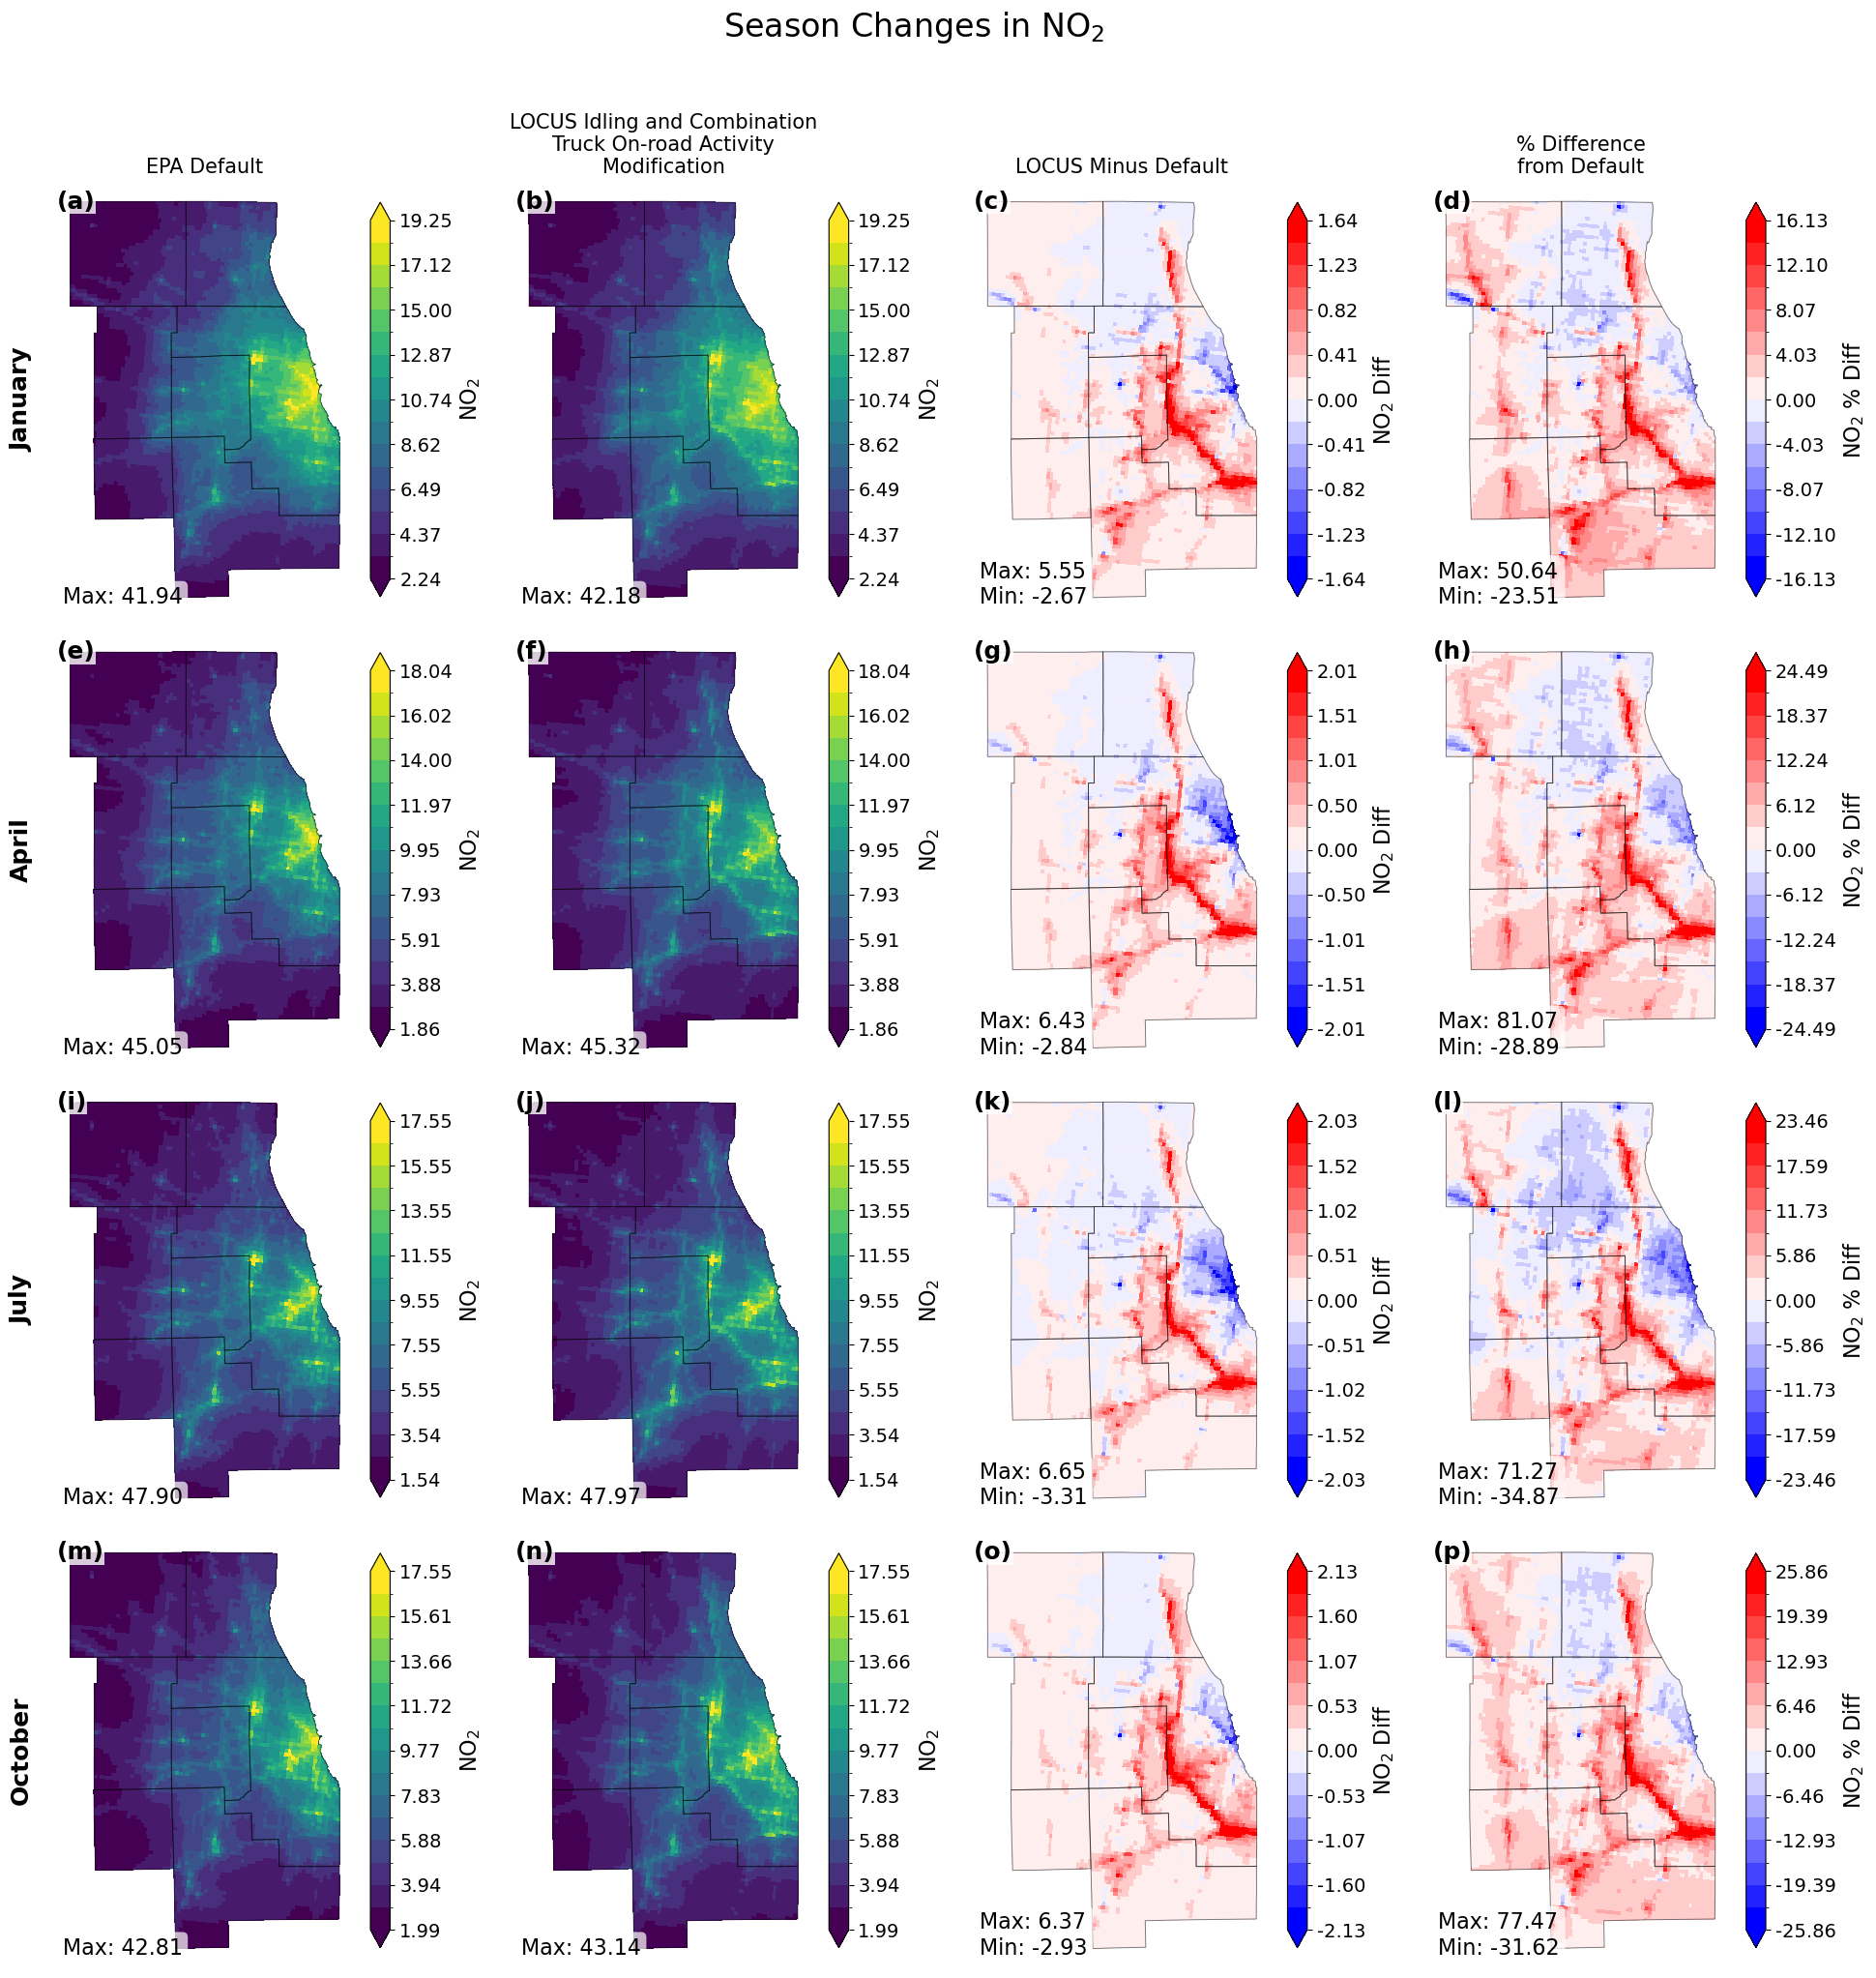

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  abs_cmap = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cm

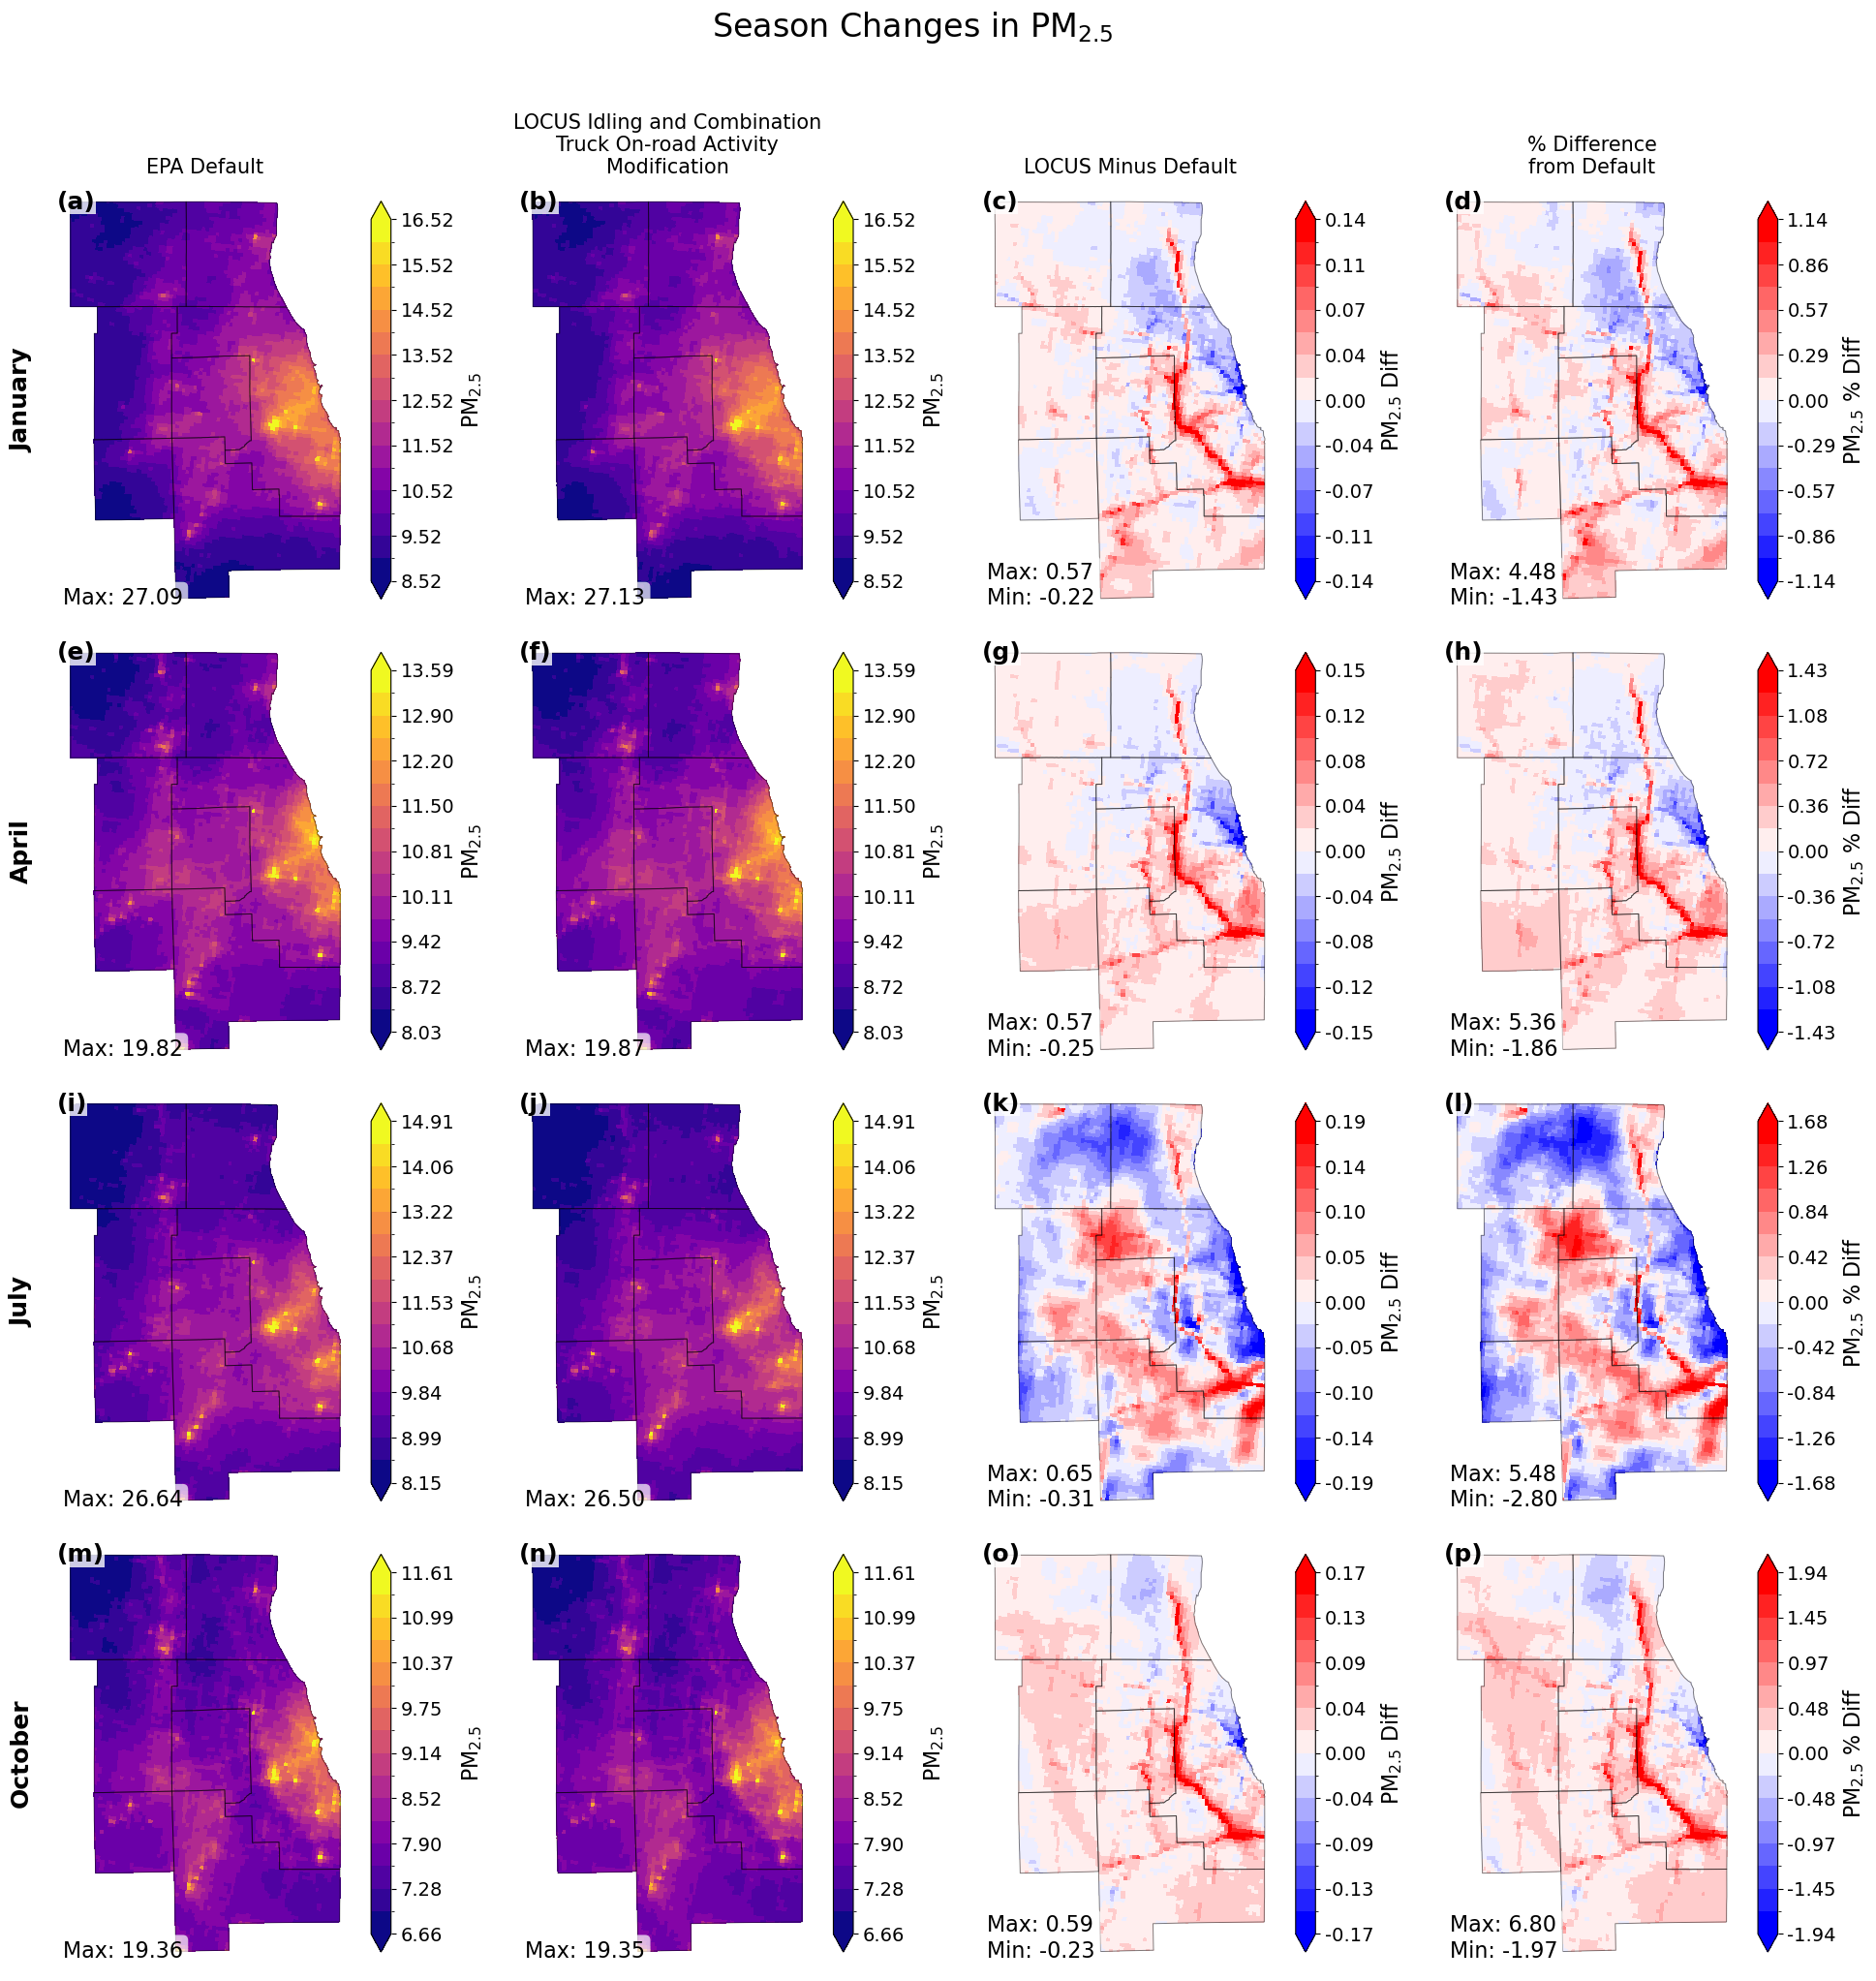

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  abs_cmap = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cm

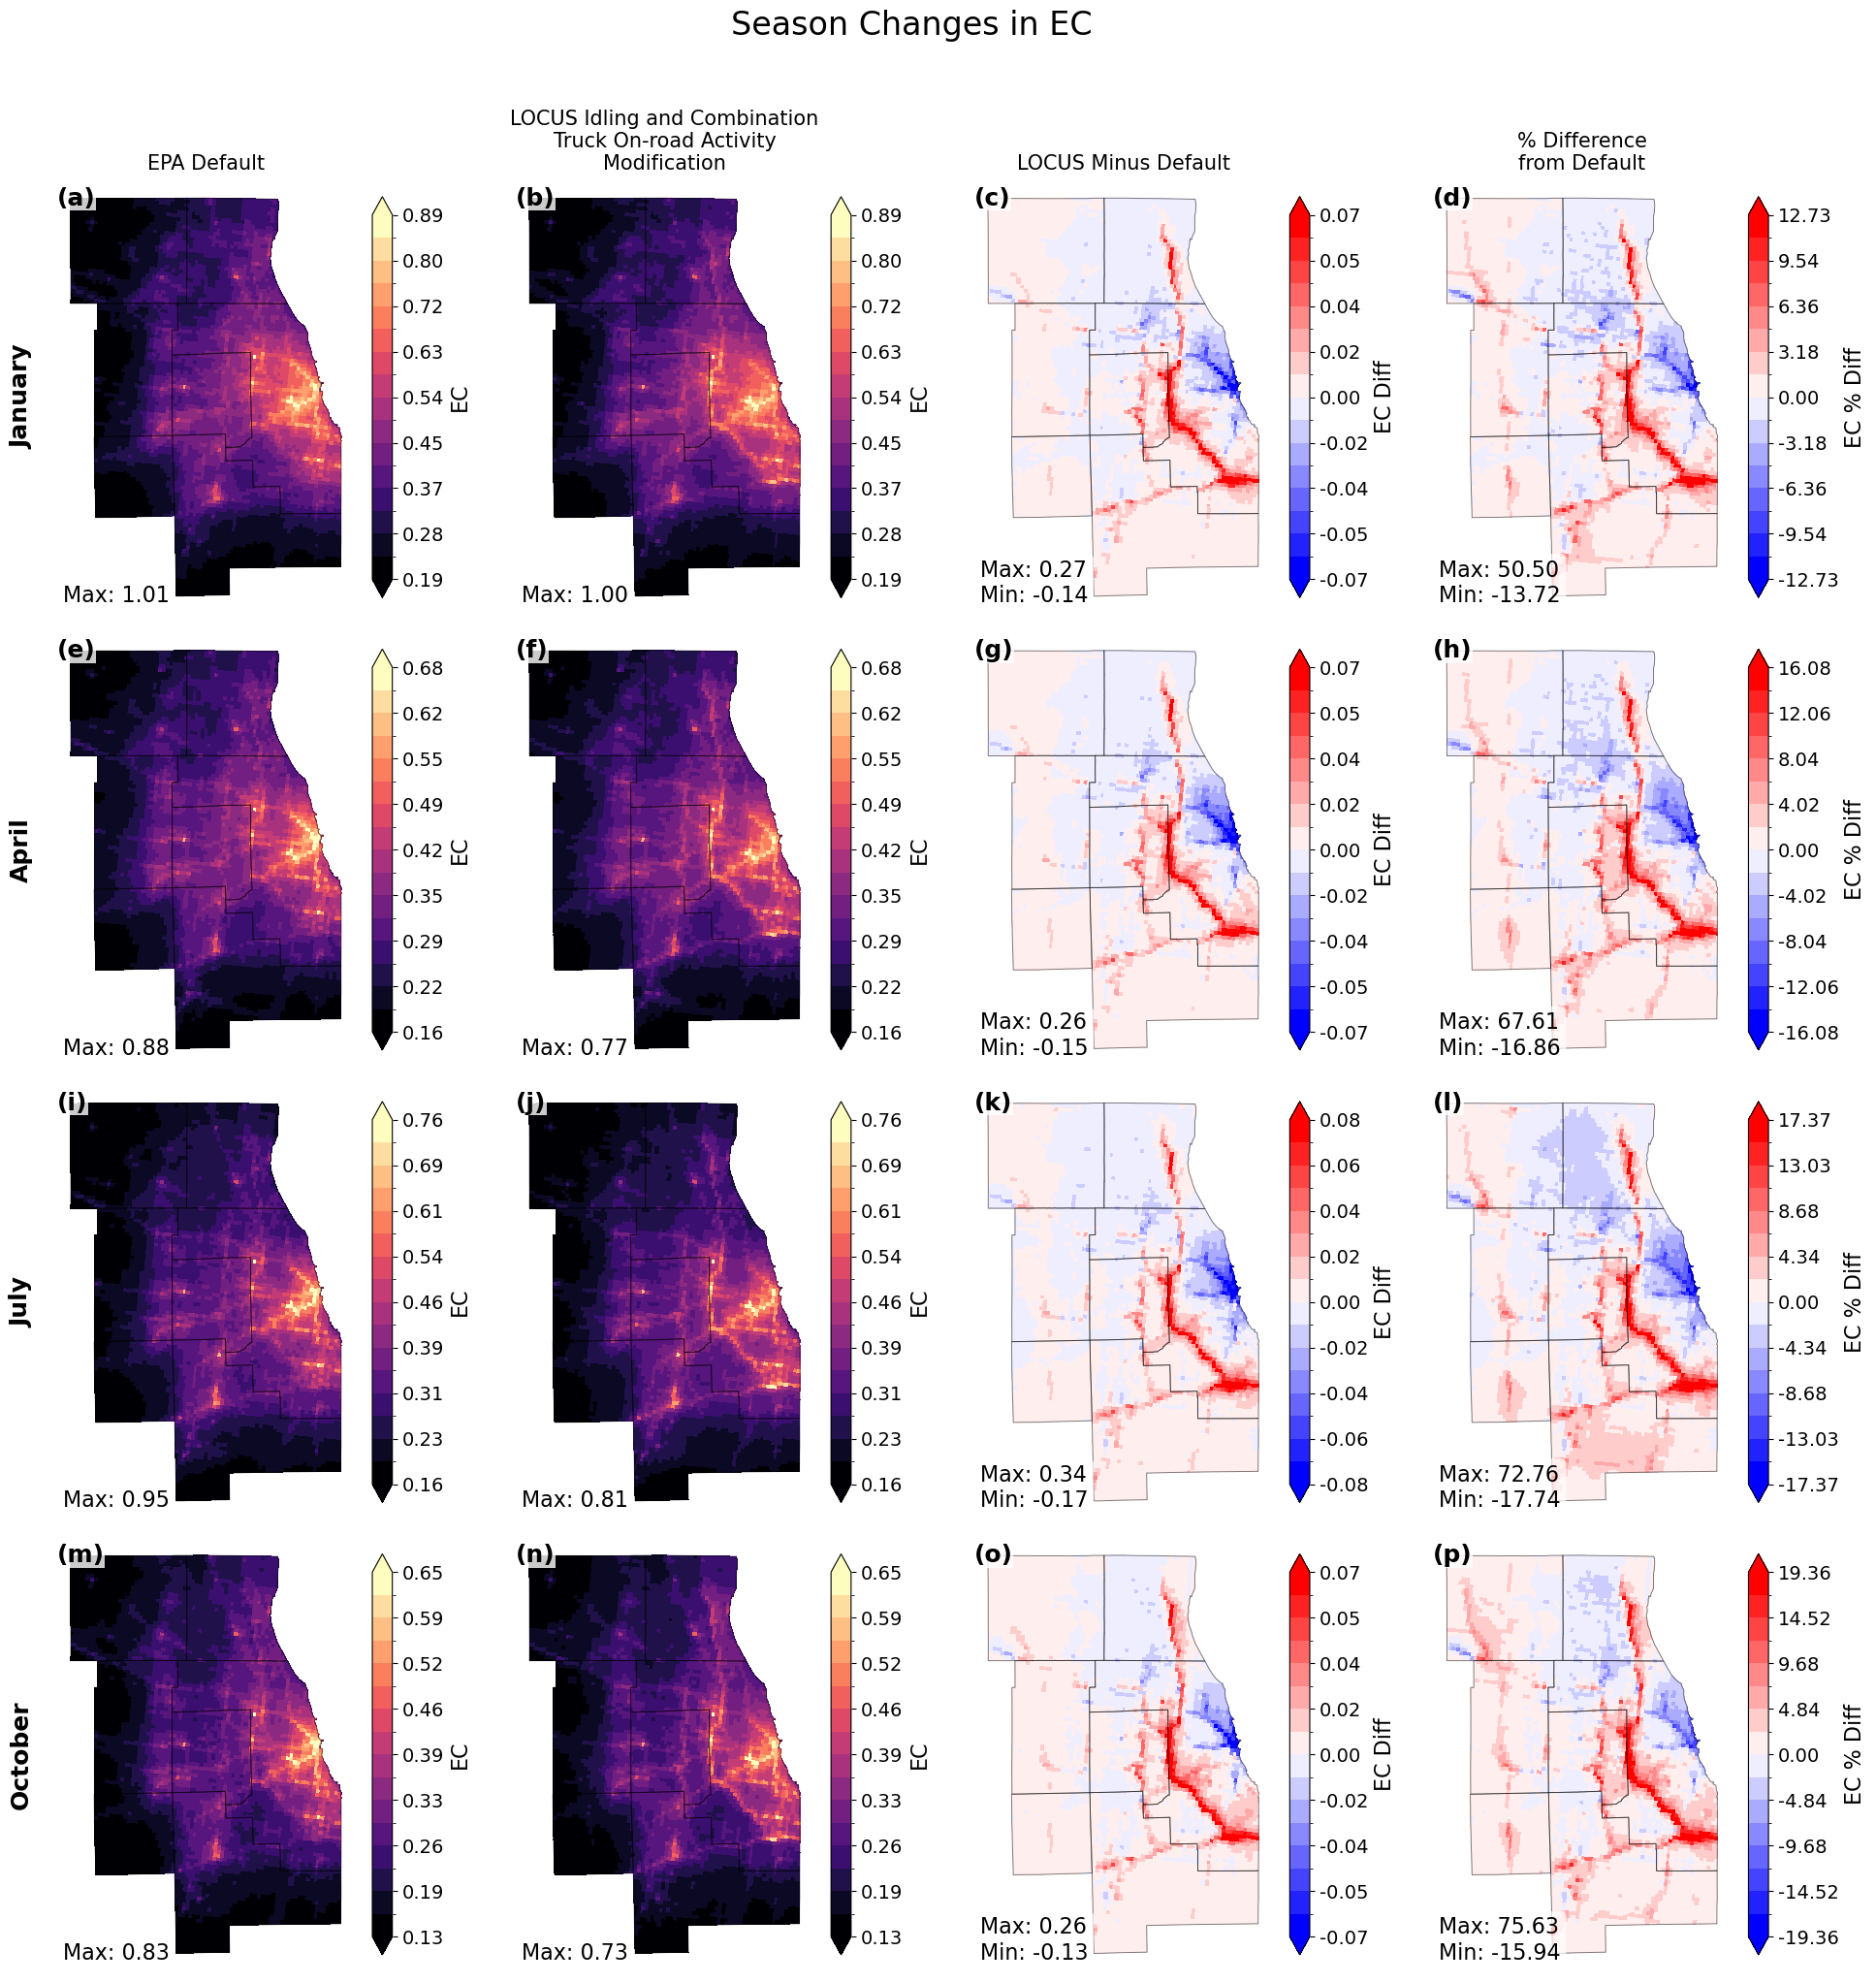

C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  abs_cmap = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_9276\290259619.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cm

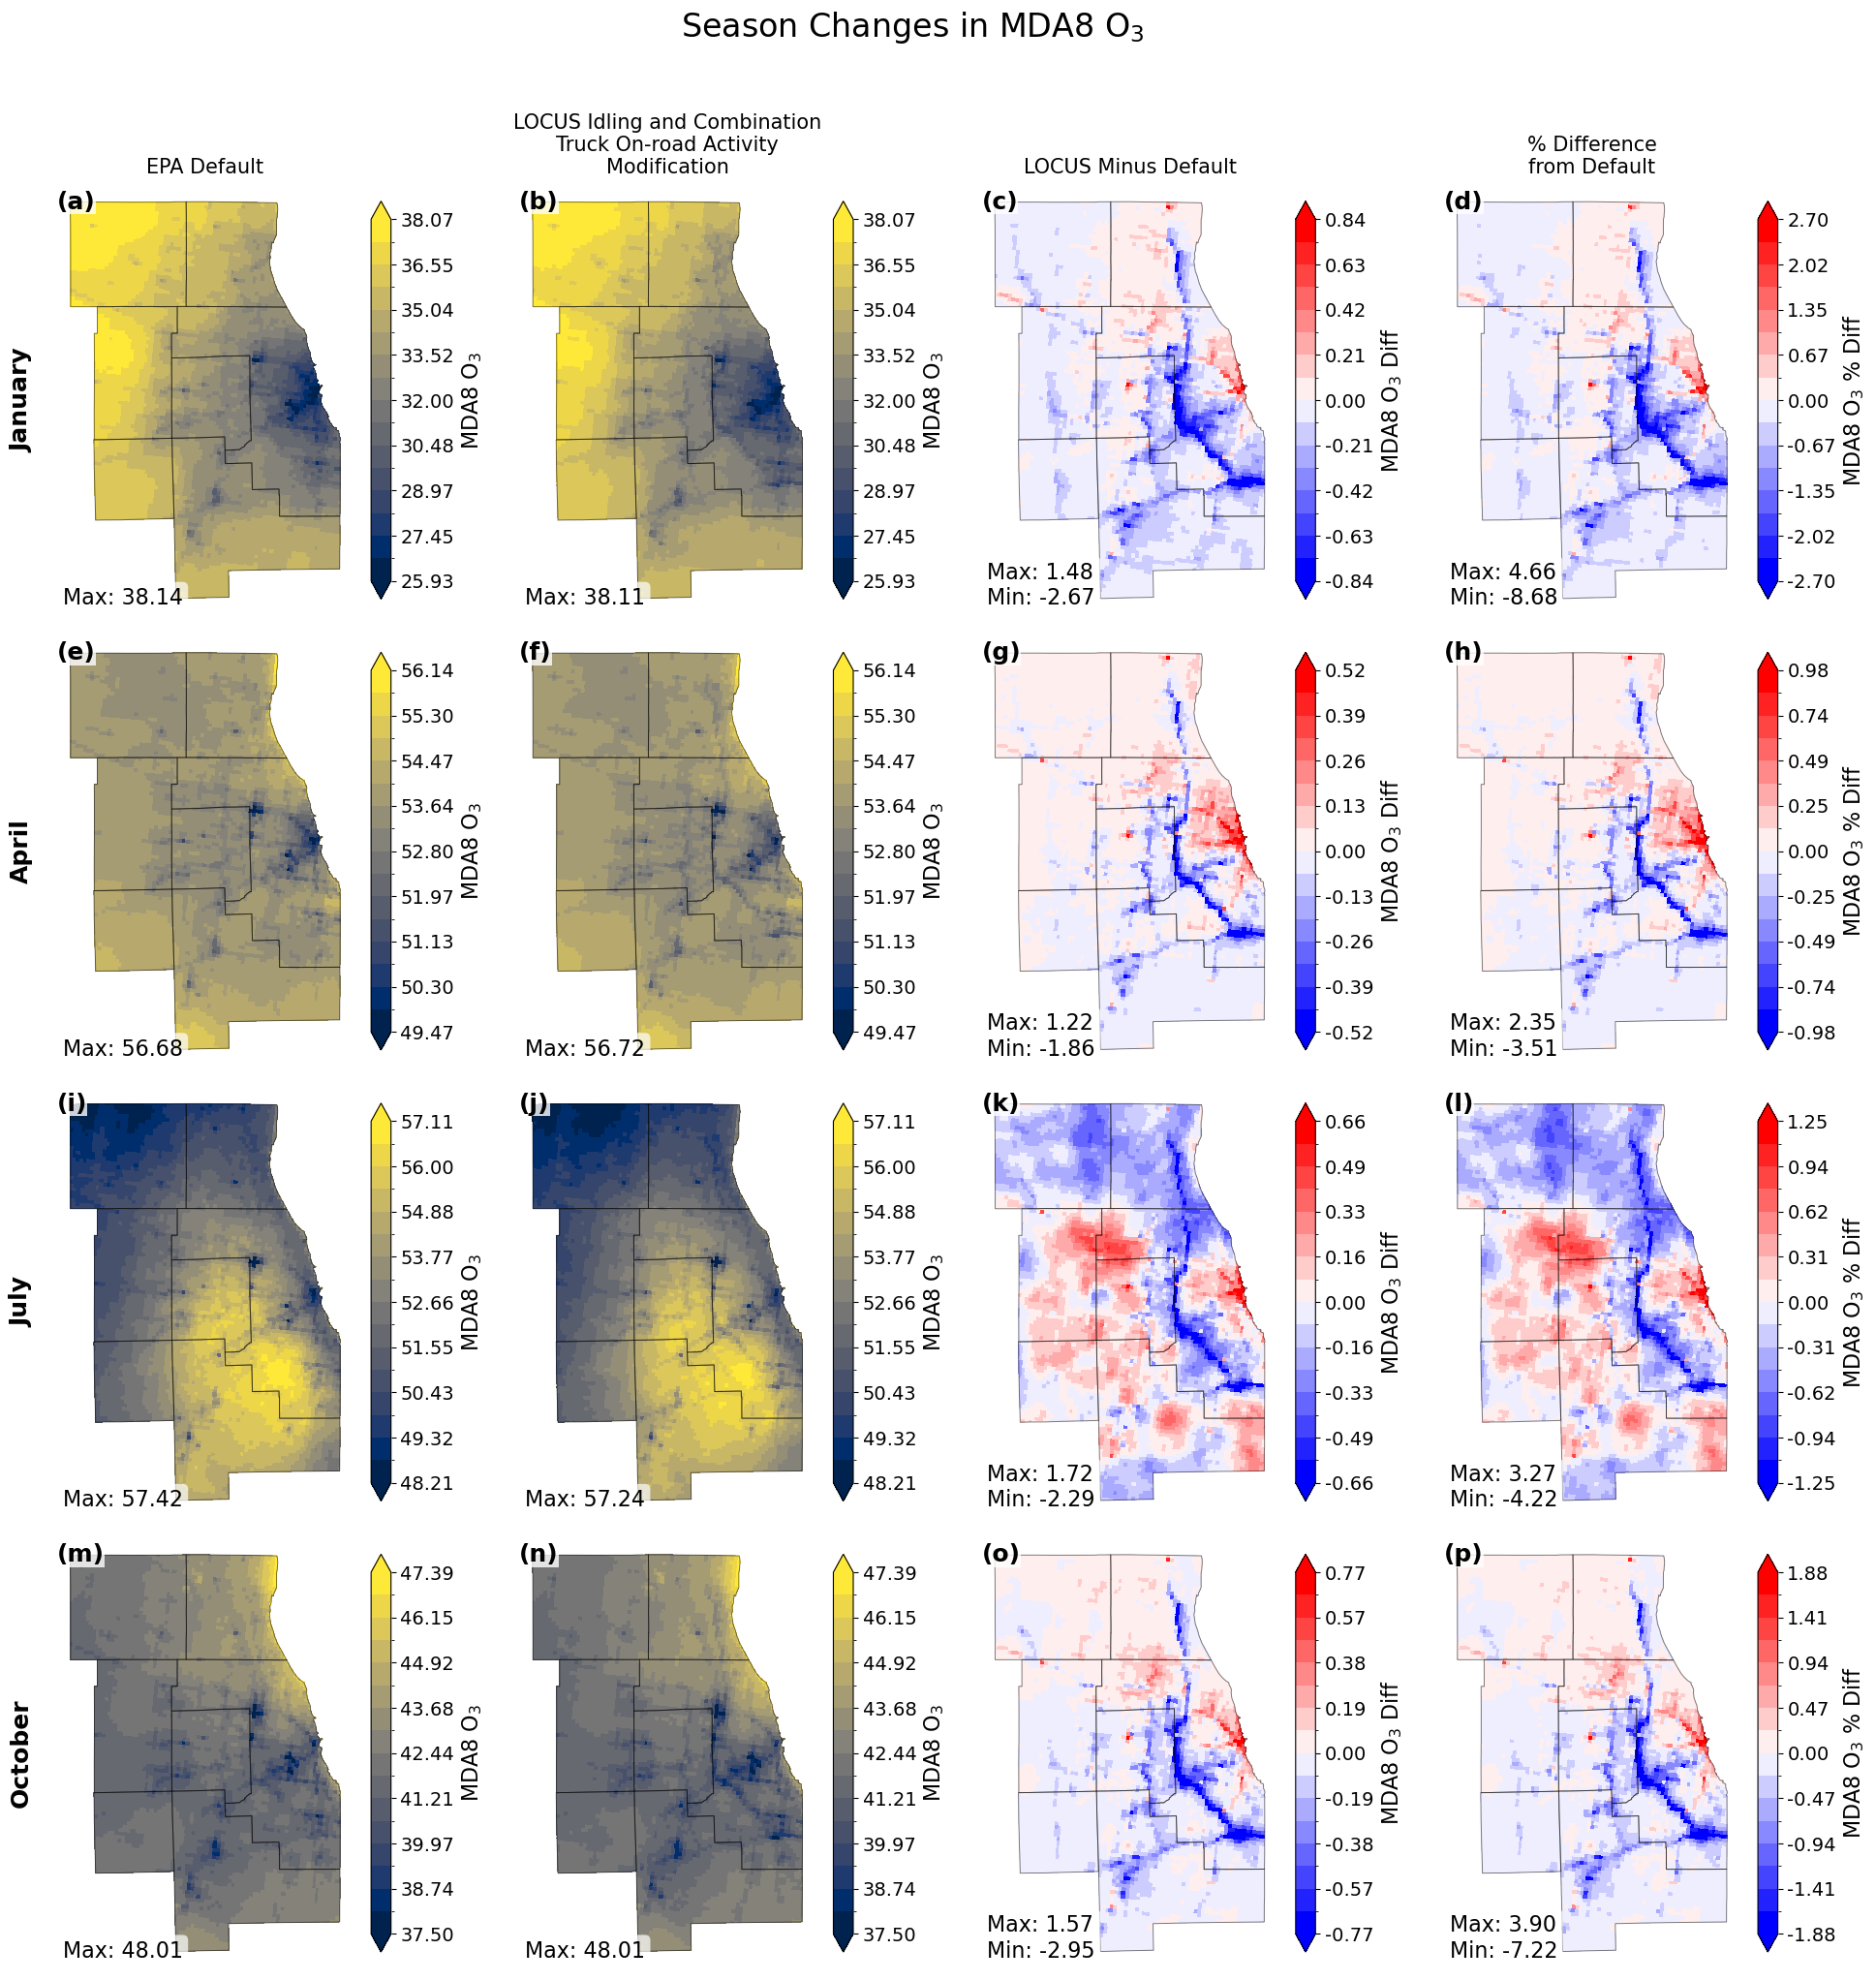

In [25]:
def plot_pollutant_monthly_rows(pol):
    cfg = plot_config[pol]
    col = cfg["column"]

    # create one row for each month and one column for each scenario comparison
    fig, axs = plt.subplots(nrows=len(months), ncols=4, figsize=(20, 20), subplot_kw={"projection": ccrs.PlateCarree()})
    fig.suptitle(f"Season Changes in {cfg['title']}", fontsize=24, y=1.02)

    for i, month in enumerate(months):
        reference_gdf = monthly_gdfs_by_pol[pol]["reference"][month]
        scenario_gdf = monthly_gdfs_by_pol[pol]["scenario"][month]

        # set a shared concentration scale between EPA Default and the modified scenario for each month
        vals_all = []

        for gdf in [reference_gdf, scenario_gdf]:
            vals = gdf[col].astype(float).to_numpy()
            vals_all.append(vals[np.isfinite(vals)])

        vals_all = np.concatenate(vals_all)
        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)
        if np.isclose(vmin, vmax): vmax = vmin + 1e-6

        abs_cmap = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
        abs_bounds = np.linspace(vmin, vmax, N_BINS + 1)
        abs_norm = BoundaryNorm(abs_bounds, abs_cmap.N)

        # calculate absolute and percent differences for each month
        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()
        diff_vals = scenario_vals - reference_vals
        pct_vals = np.where(reference_vals != 0, (diff_vals / reference_vals) * 100.0, np.nan)

        diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
        pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

        diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)
        if np.isclose(diff_lim, 0): diff_lim = 1e-6
        if np.isclose(pct_lim, 0): pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)
        diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        diff_norm = BoundaryNorm(diff_bounds, diff_cmap.N)
        pct_norm = BoundaryNorm(pct_bounds, pct_cmap.N)

        # create plotting GeoDataFrames for concentrations and scenario differences
        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = reference_gdf[col].astype(float)
        plot_scenario[pol] = scenario_gdf[col].astype(float)
        plot_diff[pol] = diff_vals
        plot_pct[pol] = pct_vals

        plot_gdfs = [plot_reference, plot_scenario, plot_diff, plot_pct]
        cmaps = [abs_cmap, abs_cmap, diff_cmap, pct_cmap]
        norms = [abs_norm, abs_norm, diff_norm, pct_norm]
        bounds_list = [abs_bounds, abs_bounds, diff_bounds, pct_bounds]

        # plot EPA Default, modified scenario, difference, and percent difference
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            panel_label = f"({chr(97 + i * 4 + j)})"
            gdf = plot_gdfs[j]

            ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2))

            gdf.plot(column=pol, ax=ax, cmap=cmaps[j], norm=norms[j], edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

            if i == 0: ax.set_title(scen, fontsize=15)
            if j == 0: ax.text(-0.08, 0.5, month_labels[month], transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=18, fontweight="bold")

            ax.set_axis_off()

            # add a separate discrete colorbar to each panel
            sm = plt.cm.ScalarMappable(norm=norms[j], cmap=cmaps[j])
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds_list[j], ticks=bounds_list[j][::2], spacing="proportional", extend="both")
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3:
                cbar.set_label(f"{cfg['label']} % Diff", fontsize=16)
            elif j == 2:
                cbar.set_label(f"{cfg['label']} Diff", fontsize=16)
            else:
                cbar.set_label(cfg["label"], fontsize=16)

            # annotate the maximum concentration or range of scenario differences
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))
            annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

            ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0))

    # finish layout and save as PNG and PDF
    plt.tight_layout()
    plt.savefig(f"Fig_Default_LOCUS_GriddedAirPoll_{pol}_MonthlyRows.png", dpi=500, bbox_inches="tight")
    plt.savefig(f"Fig_Default_LOCUS_GriddedAirPoll_{pol}_MonthlyRows.pdf", dpi=500, bbox_inches="tight")
    plt.show()


for pol in pollutants:
    plot_pollutant_monthly_rows(pol)